In [1]:
using DifferentialEquations, PyPlot, Statistics, LaTeXStrings, PyCall, LinearAlgebra, FFTW, Colors

In [2]:
ENV["PYTHON"] = "C:\\Users\\admin\\Anaconda3\\envs\\data_vis\\python.exe"

LogNorm = pyimport("matplotlib.colors").LogNorm
cmap = pyimport("cmap")

lajolla = cmap.Colormap("crameri:lajolla").to_mpl();
balance = cmap.Colormap("cmocean:balance").to_mpl();
oslo = cmap.Colormap("crameri:oslo").to_mpl();
lipari = cmap.Colormap("crameri:lipari").to_mpl();
lapaz = cmap.Colormap("crameri:lapaz").to_mpl();
rocket = cmap.Colormap("seaborn:rocket").to_mpl();
heat = cmap.Colormap("yorick:heat").to_mpl();
curl_pink = cmap.Colormap("cmocean:curl_pink").to_mpl();
arctic = cmap.Colormap("cmasher:arctic").to_mpl();
glasgow = cmap.Colormap("crameri:glasgow").to_mpl();
# Configure LaTeX rendering and fonts
PyPlot.matplotlib[:rc]("text", usetex=true)
PyPlot.matplotlib[:rc]("font", family="serif", size = 18)#serif=["mathpazo"], size=18)  # Base font size
PyPlot.matplotlib[:rc]("axes", titlesize=30)             # Axis title
PyPlot.matplotlib[:rc]("axes", labelsize=30)             # Axis labels
PyPlot.matplotlib[:rc]("xtick", labelsize=24)            # X-ticks
PyPlot.matplotlib[:rc]("ytick", labelsize=24)            # Y-ticks
PyPlot.matplotlib[:rc]("legend", fontsize=24)            # Legend
PyPlot.matplotlib[:rc]("figure", titlesize=24)           # Figure title
PyPlot.svg(true)
# LaTeX preamble packages
PyPlot.matplotlib[:rc]("text.latex", preamble="\\usepackage{amsmath}\\usepackage{amsfonts}\\usepackage{amssymb}\\usepackage{lmodern}")

In [3]:
""" 

        build Gell-Mann λ-matrices for the su(3) algebra (NOTE 1/2 factor)

"""

λ1 = 1/2 * [0 1 0;
        1 0 0;
        0 0 0]

λ2 = 1/2*[0 -im  0;
        im  0  0;
        0   0  0]

λ3 = 1/2*[1  0 0;
        0 -1 0;
        0  0 0]

λ4 = 1/2*[0 0 1;
        0 0 0;
        1 0 0]

λ5 = 1/2*[0  0 -im;
        0  0   0;
        im 0   0]

λ6 = 1/2*[0 0 0;
        0 0 1;
        0 1 0]

λ7 = 1/2*[0  0   0;
        0  0  -im;
        0  im  0]
        
λ8 = (1/(2*sqrt(3)))*[1   0   0;
                0   1   0;
                0   0  -2]

                

λ_matrices = [λ1, λ2, λ3, λ4, λ5, λ6, λ7, λ8]

sum(λ_matrices[i]^2 for i in 1:8)


"""
    su3_d_tensor(lambdas::Vector{<:AbstractMatrix})

Compute the fully symmetric d_{i,j,k} tensor for SU(3) by
d[i,j,k] = 1/4 * tr( (lambdas[i]*lambdas[j] + lambdas[j]*lambdas[i]) * lambdas[k] ).
Returns an Array{Float64,3} of size (8,8,8).
"""
function su3_d_tensor(lambdas::Vector{Matrix{ComplexF64}})
    d = zeros(Float64, 8, 8, 8)
    for i in 1:8, j in 1:8, k in 1:8
        # compute the anticommutator {λ_i, λ_j}
        A = lambdas[i]*lambdas[j] + lambdas[j]*lambdas[i]

        d[i, j, k] = tr(A * lambdas[k]) / 4
    end
    return d
end

#Sum with cubic casimir of lambda matrices
dsu3 = su3_d_tensor(λ_matrices);

C3m = zeros(ComplexF64, 3, 3)

# sum over i,j,k
for i in 1:8, j in 1:8, k in 1:8
    C3m .+= dsu3[i, j, k] * (λ_matrices[i] * λ_matrices[j] * λ_matrices[k])
end
C3m

3×3 Matrix{ComplexF64}:
 0.138889+0.0im       0.0+0.0im       0.0+0.0im
      0.0+0.0im  0.138889+0.0im       0.0+0.0im
      0.0+0.0im       0.0+0.0im  0.138889+0.0im

In [4]:
# Define function to evaluate commutators of operator A with jump operator B built from Gell-Mann matrices
function commutator_lambda(A, B)
    Bdag = conj(transpose(B))
    return (Bdag*A - A*Bdag)*B + Bdag*(A*B - B*A)
end

commutator_lambda (generic function with 1 method)

In [7]:
L = λ1 - im*λ2 + λ6 - im*λ7;

3×3 Matrix{ComplexF64}:
 0.0+0.0im  0.0-1.0im  0.0+0.0im
 0.0+1.0im  0.0+0.0im  0.0+0.5im
 0.0+0.0im  0.0-0.5im  0.0+0.0im

In [8]:
N1m = I(3)/3 + λ3 + 1/sqrt(3)*λ8
N0m = I(3)/3 - λ3 + 1/sqrt(3)*λ8
N2m = I(3)/3 - 2/sqrt(3)*λ8;

In [9]:
A = 7/10
γ = 0
β = 0
B = 1/10
C = sqrt(1-A^2-B^2)

a1 = A*B*cos(β)
a2 = A*B*sin(β)
a3 = 1/2*(A^2-B^2)
a4 = A*C*cos(γ)
a5 = A*C*sin(γ)
a6 = B*C*cos(γ-β)
a7 = B*C*sin(γ-β)
a8 = (-2+3*A^2+3B^2)/(2*sqrt(3))

# a1 = 0
# a2 = 0
# a3 = 0
# a4 = 0
# a5 = 0
# a6 = 0
# a7 = 0
# a8 = 0

# Definition of density matrix
rho0 = [1/3+a3+a8/sqrt(3) a1-im*a2 a4-im*a5;
a1+im*a2 1/3-a3+a8/sqrt(3) a6-im*a7;
a4+im*a5 a6+im*a7 1/3-2/sqrt(3)*a8]

# Physicality checks on rho & entries
det(rho0)
avec = [a1,a2,a3,a4,a5,a6,a7,a8]
sum(avec.^2)

0.33333333333333337

In [11]:
# Normalize

O = [0;1;0]
A = [1;0;0]
B = [0;0;1]
a = 1/sqrt(2)
b = -1/sqrt(2)
c = sqrt(1-a^2-b^2)
psi = a * A + b*B + c*O
rho0 = psi*psi'
rho0 = rho0 / tr(rho0)

3×3 Matrix{Float64}:
  0.5          1.05367e-8   -0.5
  1.05367e-8   2.22045e-16  -1.05367e-8
 -0.5         -1.05367e-8    0.5

In [12]:
C3m = zeros(ComplexF64, 3, 3)
for i in 1:8, j in 1:8, k in 1:8
    C3m .+= (rho0 * dsu3[i, j, k] * (λ_matrices[i] * λ_matrices[j] * λ_matrices[k]))
end
tr(C3m)


# tr(rho0*λ8)

0.13888888888888892 + 0.0im

In [14]:
""" 

MEAN FIELD EQUATIONS

    for Gell-Mann λ_i (i=1..8) and cavity field α 

""" 
function coupled_eqs!(du, u, p, t)
    Δ1, Δ2, g, φ, Δ, κ, η, γ = p
    λ1, λ2, λ3, λ4, λ5, λ6, λ7, λ8, α_re, α_im = u

    # reconstruct complex field
    α    = α_re + im*α_im
    αc   = conj(α)
    expp = cis(φ)               # e^{iφ}
    expm = conj(expp)           # e^{-iφ}

    # λ-derivatives 
    dλ1 = -Δ1*λ2 + im*g*(λ3*(α-αc) + expm*αc/2*(-im*λ5+λ4) + expp*α/2*(-im*λ5-λ4)) + γ* (λ1*λ3 - 1/2 *(λ4*λ6  + λ5*λ7))
    dλ2 =  Δ1*λ1 + im*g*(im*λ3*(α+αc) + expm*αc/2*(im*λ4+λ5) + expp*α/2*(im*λ4-λ5)) + γ*(λ2*λ3 + 1/2 *(λ4*λ7  - λ5*λ6))
    dλ3 =  im*g*(-im*λ2*(α+αc) + λ1*(αc-α) + expm*αc/2*(im*λ7-λ6) + expp*α/2*(im*λ7+λ6)) + γ*(-λ1^2 - λ2^2 + 1/2*(λ6^2+λ7^2))
    dλ4 = (-Δ1-Δ2)*λ5 + im*g*(αc/2*(im*λ7+λ6) + α/2*(im*λ7-λ6) + expm*αc/2*(-im*λ2-λ1) + expp*α/2*(-im*λ2+λ1)) 
    dλ5 = -(-Δ1-Δ2)*λ4 + im*g*(αc/2*(-im*λ6+λ7) + α/2*(-im*λ6-λ7) + expm*αc/2*(im*λ1-λ2) + expp*α/2*(im*λ1+λ2))
    dλ6 = -(Δ2)*λ7 + im*g* ( αc/2*(im*λ5-λ4) + α/2*(im*λ5+λ4) + 1/2*(expp*α - expm*αc)*(sqrt(3)*λ8 - λ3)) + γ/2*(λ1*λ4 + λ2*λ5 - λ3*λ6 + sqrt(3)*λ6*λ8)              
    dλ7 =  (Δ2)*λ6 + im*g* ( αc/2*(-im*λ4-λ5) + α/2*(-im*λ4+λ5) + 1/2*(expp*α + expm*αc)*(im*sqrt(3)*λ8 - im*λ3)) + γ/2*(λ1*λ5 - λ2*λ4 - λ3*λ7 + sqrt(3)*λ7*λ8)          
    dλ8 = -im*sqrt(3)/2*g*(αc*expm*(im*λ7-λ6) + α*expp*(im*λ7+λ6))-γ*λ8 + γ/2 * (-sqrt(3)*λ6^2 -sqrt(3)*λ7^2)

    du[1] = dλ1
    du[2] = dλ2
    du[3] = dλ3
    du[4] = dλ4
    du[5] = dλ5
    du[6] = dλ6
    du[7] = dλ7
    du[8] = dλ8

    # α-equation (split into real and imaginary parts)
    dα = (Δ*im - κ/2)*α - im*g*((λ1 - im*λ2) + expm*(λ6 - im*λ7)) + η
    du[9]  = real(dα)
    du[10] = imag(dα)
end  

coupled_eqs!

$\mathfrak{su}(3)$ quadratic and cubic Casimir operators $C_2$, $C_3$, define and check they remain constant over time

In [15]:
# Fixed parameters
g, κ = 0.1, 1.0
γ = 0
Δ1, Δ2 = 0,0 
Δ = 0
ϕ = 0
η = 0.01*g 
# Time steps
tend = 2000.0/g;
t_list = range(0.0, tend, length=10001);

# Initial conditions
u0 = zeros(10);  
for i in 1:8
    u0[i] = tr(rho0*λ_matrices[i])
end

In [75]:
# Initial normalization checks: population, quadratic and cubic casimirs.
λt = sum([u0[i]^2 for i in 1:8])

C3 = 0
for i in 1:8, j in 1:8, k in 1:8
    C3 += sum(dsu3[i,j,k] * u0[i] * u0[j] * u0[k])
end



println("C₂ initial: ", λt)
println("C₃ initial: ", C3)
println("N₀ initial: ", (1/3 - u0[3] + 1/sqrt(3)*u0[8]))
println("N₁ initial: ", (1/3 + u0[3] + 1/sqrt(3)*u0[8]))
println("N₂ initial: ", (1/3 - 2/sqrt(3)*u0[8]))

C₂ initial: 0.3333333333333333
C₃ initial: 0.013888888888888885
N₀ initial: 1.8041124150158794e-16
N₁ initial: 0.49999999999999983
N₂ initial: 0.4999999999999999


In [76]:
params = (Δ1, Δ2, g, ϕ, Δ, κ, η, γ);
prob = ODEProblem(coupled_eqs!, u0, (0.0, tend), params);
sol = solve(prob, Tsit5(), saveat=t_list, reltol=1e-9, abstol=1e-9; maxiters=1e9);  # If stiff solver needed → pass "TRBDF2(autodiff=false)" to solve()

In [77]:

# extract lambdas and times
λ = sol[1:8, :]         
t = sol.t              
Nt = length(t)

# Compute Ni populations 
N0 = (1/3 .- sol[3,:] .+ 1/sqrt(3).*sol[8,:])
N1 = (1/3 .+ sol[3,:] .+ 1/sqrt(3).*sol[8,:])
N2 =  (1/3 .- 2/sqrt(3).*sol[8,:])
Nt = N0 .+ N1 .+ N2
C2 = sum(λ .^ 2, dims=1)[:]   # quadratic Casimir
adaga = sol[9,:].^2 .+ sol[10,:].^2  # |α|²


# cubic Casimir C3(t)
Ntsteps = length(sol.t)
dsu3 = su3_d_tensor(λ_matrices);
C3 = zeros(Float64, Ntsteps)
@inbounds for ti in 1:Ntsteps
    for i in 1:8, j in 1:8, k in 1:8
        C3[ti] += dsu3[i,j,k] * λ[i,ti] * λ[j,ti] * λ[k,ti]
    end
end

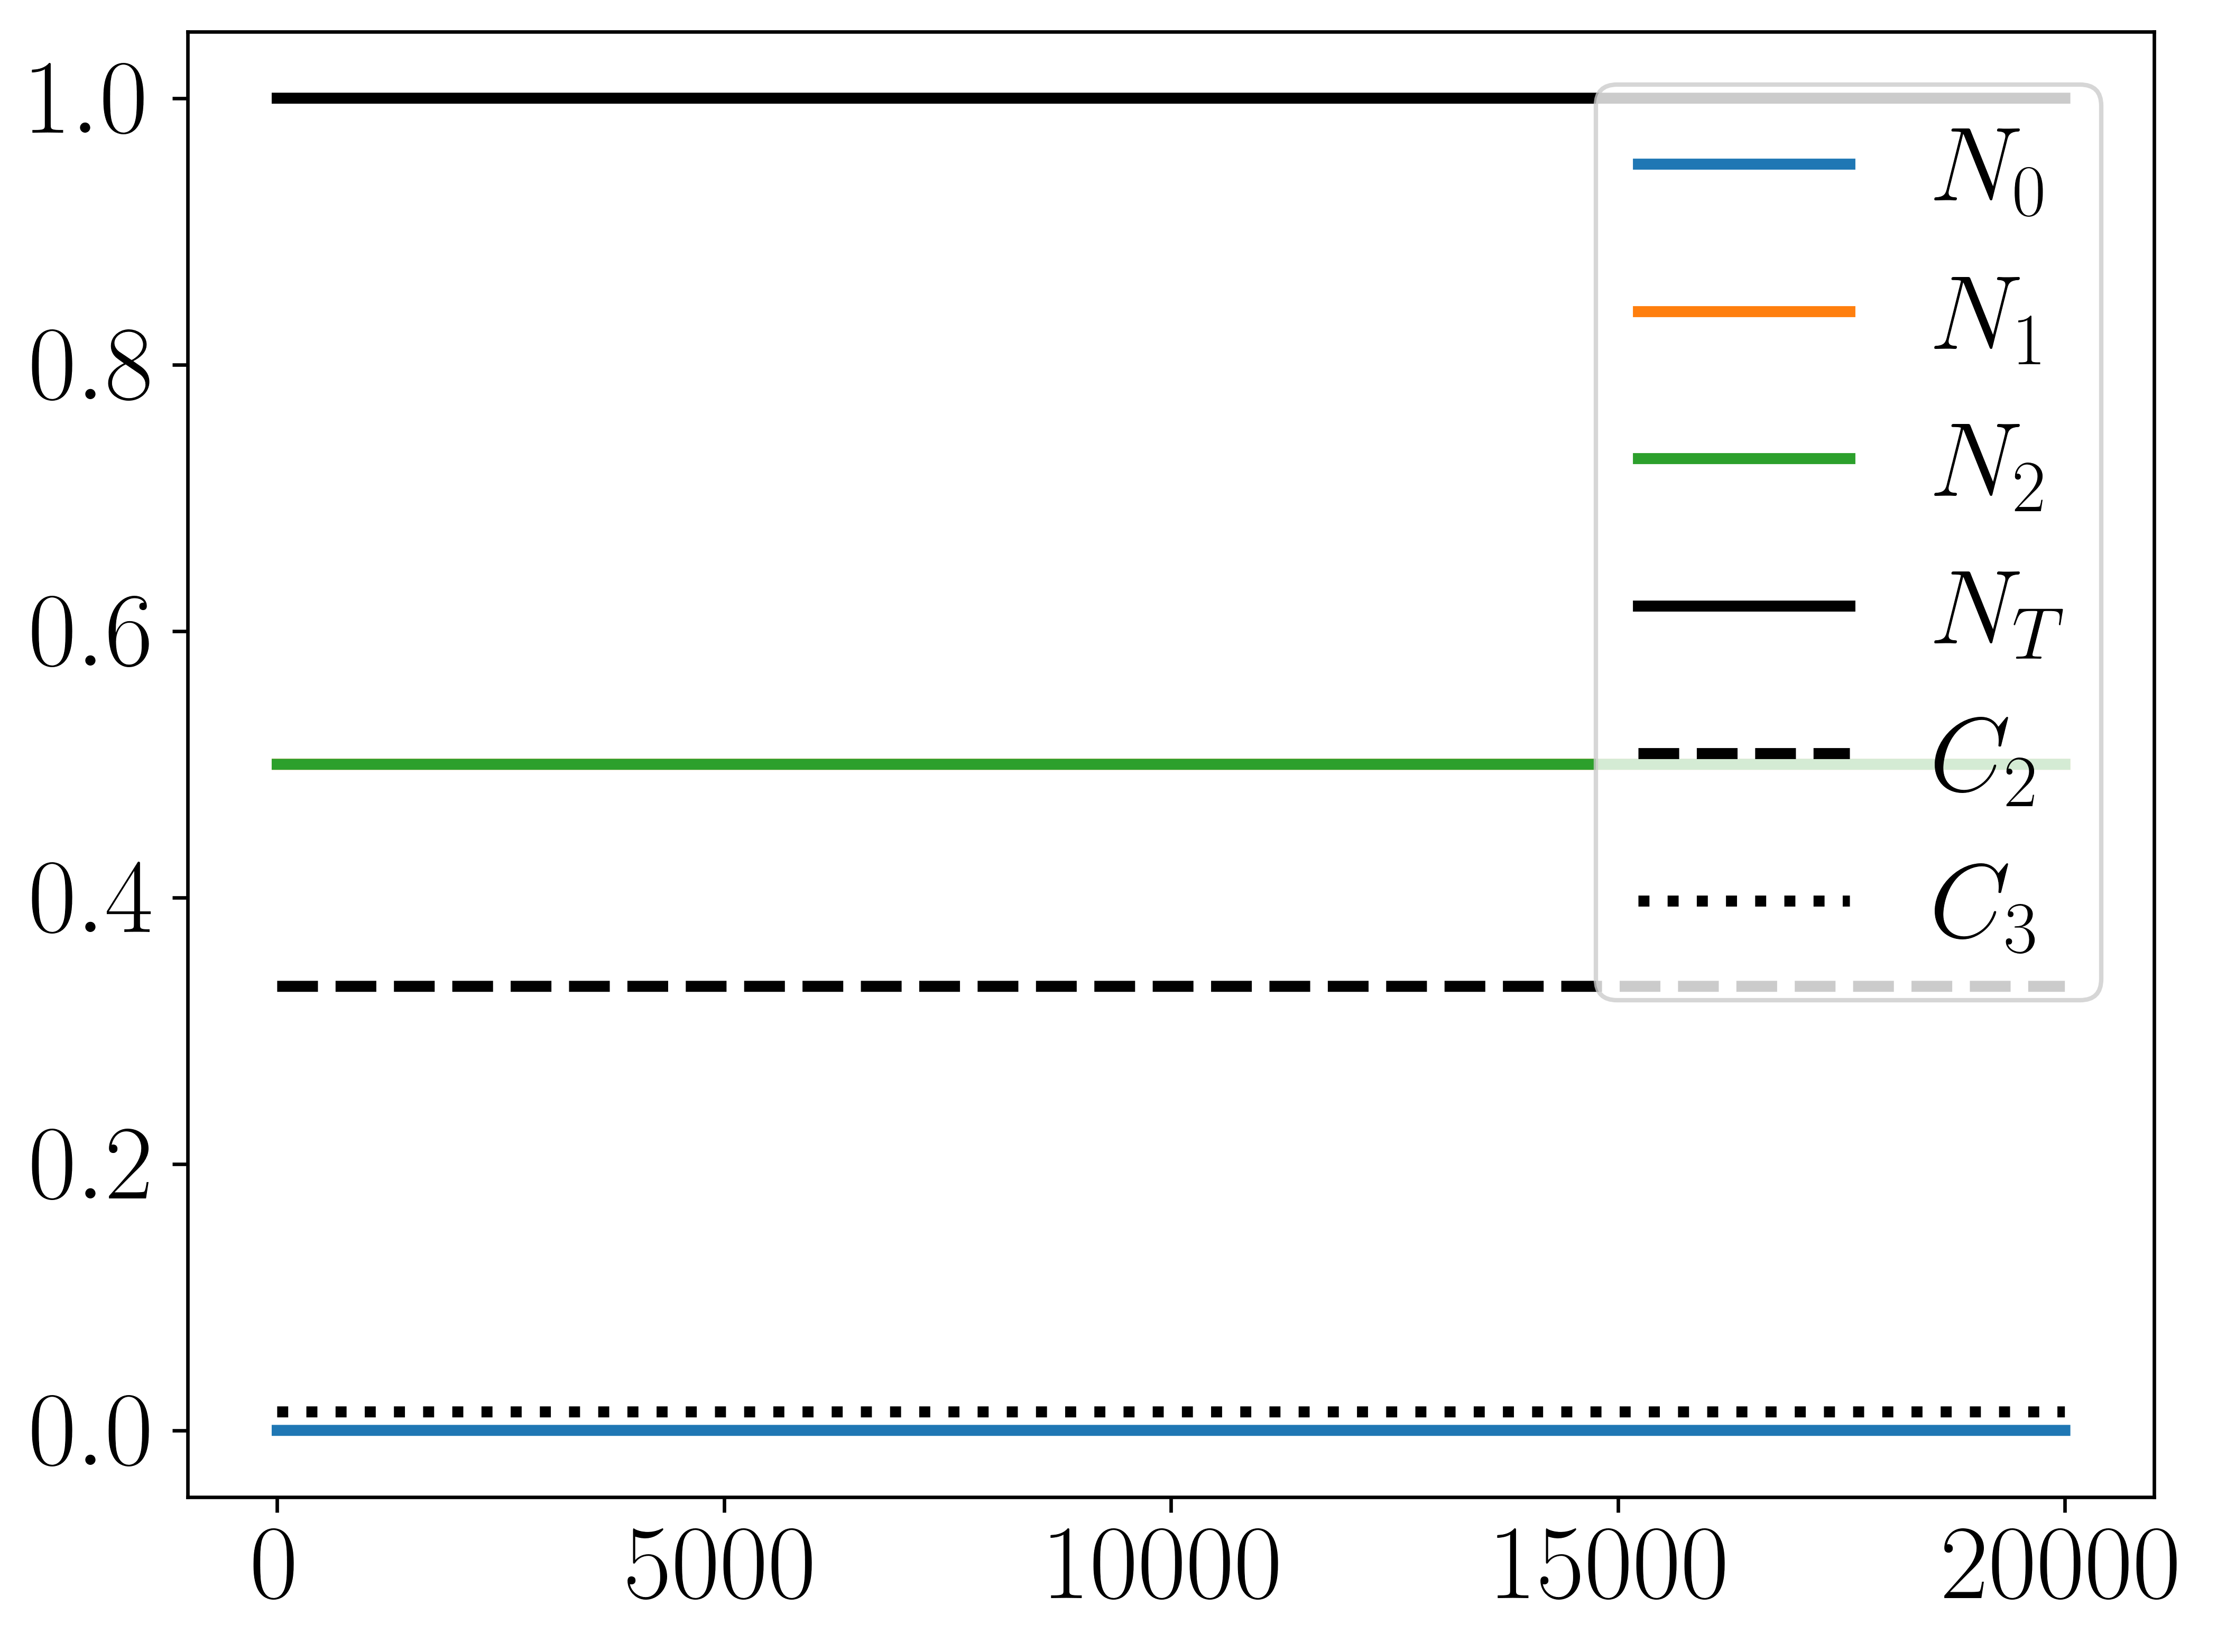

In [78]:
fig, ax= subplots(figsize=(8, 6), dpi=600)
ax.plot(t, N0, lw=2.5, label=L"N_0")
ax.plot(t, N1, lw=2.5, label=L"N_1")
ax.plot(t, N2, lw=2.5, label=L"N_2")
ax.plot(t, Nt, lw=2.5, linestyle="-", color="black", label=L"N_T")
ax.plot(t, C2, lw=2.5, linestyle="--", color="black", label=L"$C_2$")
ax.plot(t, C3, lw=2.5, linestyle=":", color="black", label=L"$C_3$")
#ax.plot(t, adaga, lw=2.5, color="crimson", label=L"$|\alpha|^2$")
# ax.plot(t, sol[1,:] + sol[6,:], label=L"1,6", lw=4)
# ax.plot(t, sol[3,:] + sqr't(3)*sol[8,:], label=L"3,8", lw4)
# ax.plot(t, sol[2,:] + sol[7,:], label=L"2,7", lw=4)
# ax.plot(t, (sol[1,:] .+ sol[6,:]).^2 + (sol[3,:] .+ sqrt(3)*sol[8,:]).^2 .+ (sol[2,:] .+ sol[7,:]).^2, label="tot", lw=4)
# ax.set_xscale("log")
ax.legend(loc="upper right")
display(fig)

In [15]:
using DelimitedFiles


writedlm("../simul/N0_alt2.txt", N0)
writedlm("../simul/N1_alt2.txt", N1)
writedlm("../simul/N2_alt2.txt", N2)

In [ ]:
#Sample data 


n = length(N1)

Fs = 1/(t[2] - t[1])  # Replace with your sampling frequency (Hz)

# Preprocess data
N0_detrend = N1 .- mean(N1)
window = 0.5 .* (1 .- cos.(2π .* (0:n-1) ./ (n-1)))
N0_windowed = N0_detrend .* window

# Compute FFT

fft_N0 = fft(N1)
mag = abs.(fft_N0)

# One-sided spectrum adjustment
if n % 2 == 0
    mag_one_sided = mag[1:(n÷2 + 1)]
    mag_one_sided[2:end-1] .*= 2
else
    mag_one_sided = mag[1:((n+1) ÷ 2)]
    mag_one_sided[2:end] .*= 2
end

# Frequency axis
freq = Fs .* (0:(length(mag_one_sided)-1)) ./ n


In [ ]:
fig, ax = subplots(figsize=(8, 4), dpi=600)
plot(freq[2:end]./g, mag_one_sided[2:end],  label="FFT amplitude", lw=2.5)
xlim(0,1)
xlabel(L"Frequency $(\omega g)$")
ylabel(L"|Y(f)|")
legend()
tight_layout()
display(fig)

In [ ]:
minimum(hcat(N0, N1, N2))

Map out mean field phase diagram 

In [99]:
# Parameter setup
η_vals = range(0.1*g, 1.0*g, length=41)
φ_vals = range(-π, π, length=41)
# Δ_vals = range(-1.0*g, 1.0*g, length=41)

# Preallocate variance and mean arrays
var_N0 = zeros(length(φ_vals), length(η_vals))
var_N1 = zeros(length(φ_vals), length(η_vals))
var_N2 = zeros(length(φ_vals), length(η_vals))
var_adaga = zeros(length(φ_vals), length(η_vals))
var_argcav = zeros(length(φ_vals), length(η_vals))


mean_N0 = zeros(length(φ_vals), length(η_vals))
mean_N1 = zeros(length(φ_vals), length(η_vals))
mean_N2 = zeros(length(φ_vals), length(η_vals))
mean_adaga = zeros(length(φ_vals), length(η_vals))
mean_argcav = zeros(length(φ_vals), length(η_vals))


# coherence arrays
mean_rho01 = zeros(length(φ_vals), length(η_vals))
var_rho01  = zeros(length(φ_vals), length(η_vals))
mean_rho02 = zeros(length(φ_vals), length(η_vals))
var_rho02  = zeros(length(φ_vals), length(η_vals))
mean_rho12 = zeros(length(φ_vals), length(η_vals))
var_rho12  = zeros(length(φ_vals), length(η_vals))
# --------------------------------------------------

#Circular statistics
circ_var_argcav = zeros(length(φ_vals), length(η_vals))
circ_mean_argcav = zeros(length(φ_vals), length(η_vals))


# Steady-state window: last 40% of the time series
total_pts = length(t_list)
ss_start = round(Int, 0.6 * total_pts):total_pts

# Loop over φ and η
for (i, φ_val) in enumerate(φ_vals)
    for (j, η_val) in enumerate(η_vals)
        # Update parameters and initial condition
        params = (0*g, 0*g, g, φ_val, Δ, κ, η_val)
        prob = ODEProblem(coupled_eqs!, u0, (0.0, tend), params)

        # Solve
        sol = solve(prob, Tsit5(), saveat=t_list, reltol=1e-6, abstol=1e-6)



        # Extract steady-state data
        N0_ss =  1/3 .- sol[3,ss_start] + 1/sqrt(3) .* sol[8,ss_start];
        N1_ss = 1/3 .+ sol[3,ss_start] + 1/sqrt(3) .* sol[8,ss_start];
        N2_ss = 1/3 .- 2/sqrt(3) .* sol[8,:];
        ax_ss = sol[end-1,ss_start]
        ap_ss = sol[end,ss_start]
        argcav_ss = angle.(ax_ss + 1im*ap_ss)  # Argument of the cavity field
        adaga_ss = ax_ss.^2 + ap_ss.^2  # Adaga = |a|^2
        
        λ1_ss = sol[1, ss_start]
        λ2_ss = sol[2, ss_start]
        λ4_ss = sol[4, ss_start]
        λ5_ss = sol[5, ss_start]
        λ6_ss = sol[6, ss_start]
        λ7_ss = sol[7, ss_start]

        # --- build coherences in SS window
        rho01_ss = @. (λ1_ss + im*λ2_ss) / 2
        rho02_ss = @. (λ6_ss + im*λ7_ss) / 2
        rho12_ss = @. (λ4_ss + im*λ5_ss) / 2
    
        # --- record mean and variance of the absolute value
        mean_rho01[i,j] = mean(abs.(rho01_ss))
        var_rho01[i,j]  = var(abs.(rho01_ss))
    
        mean_rho02[i,j] = mean(abs.(rho02_ss))
        var_rho02[i,j]  = var(abs.(rho02_ss))
    
        mean_rho12[i,j] = mean(abs.(rho12_ss))
        var_rho12[i,j]  = var(abs.(rho12_ss))
        # Compute variances and mean
        var_N0[i, j] = var(N0_ss)
        var_N1[i, j] = var(N1_ss)
        var_N2[i, j] = var(N2_ss)
        var_adaga[i, j] = var(adaga_ss)
        var_argcav[i, j] = var(argcav_ss)

        # Compute means
        mean_N0[i,j] = mean(N0_ss)
        mean_N1[i,j] = mean(N1_ss)
        mean_N2[i,j] = mean(N2_ss)
        mean_adaga[i,j] = mean(adaga_ss)
        mean_argcav[i,j] = mean(argcav_ss)


    end
end

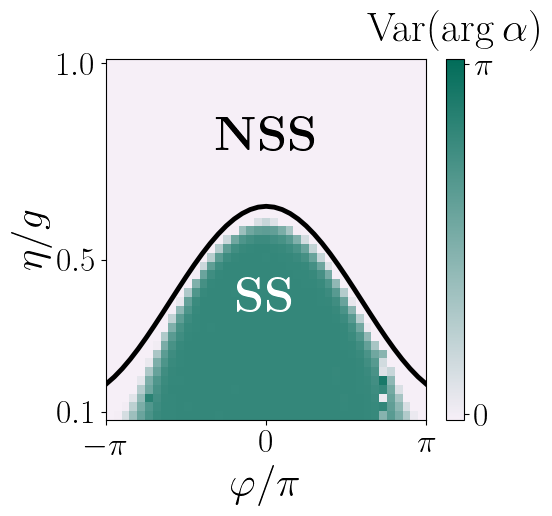

In [ ]:
### Phase diagram of the cavity field (phase or amplitude variance)

@pyimport matplotlib.colors as mcolors

# Choose two clearly distinct pastel hex‐colors:
#   - pastel_blue  = "#aec6cf"
#   - pastel_peach = "#ffdab9"
#
# (These could be any two colors you like, e.g. ["#377eb8", "#e41a1c"] for a stronger contrast.)
#cmap = mcolors.ListedColormap(["#f6eff7", "#016c59"])
cmap = PyPlot.matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#f6eff7", "#016c59"])
"""
Plot the variance phase diagram.

"""
x = φ_vals./π
y = η_vals./g
# x = Δ_vals./g
clims =  (0,pi) #(1e-3, 1e-0) 
cmap = cmap#"binary"

xtick_locs = [-1.0, 0,  1.0]  # x = φ/π
xtick_labels = [L"-\pi", L"0", L"\pi"]
ytick_locs = [0.12, 0.5, 0.99]  # y = η/g
ytick_labels = [L"0.1", L"0.5", L"1.0"]

fig, axs = subplots(1, 1, figsize=(5.5, 5.5))


im1 = imshow((var_argcav .% π)",
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=cmap, clim = clims)     
axs.set_ylabel(L"\eta/g")
axs.set_xlabel(L"\varphi/\pi")

axs.set_xticks(xtick_locs)
axs.set_xticklabels(xtick_labels)
axs.set_yticks(ytick_locs)
axs.set_yticklabels(ytick_labels)


fncx = (0.238 .* (cos.(0.83.*x.* pi)) .+0.395) # Function for the line in the phase diagram
axs.plot(x, fncx, color="black", linewidth=3.5)

cbar = colorbar(im1, ax=axs)

#Cbar ticks
cbar.set_ticks([0.05, 3.1])
cbar.set_ticklabels([L"0", L"\pi"])

#Set colorbar label as the variance of N1 and N2, horizontally aligned on top of the colorbar
cbar.ax.set_title(L"\mathrm{Var}(\arg{\alpha})", pad=13)

#Add text description to the two states inside phase diagram
axs.text(0.0, 0.4, L"\textbf{SS}", fontsize=35, ha="center", va="center", color="white")
axs.text(0.0, 0.8, L"\textbf{NSS}", fontsize=35, ha="center", va="center",color="black")
tight_layout()
display(fig)
#savefig("../figs/spin1/var_argcav.pdf", bbox_inches="tight", dpi=800)

In [ ]:
"""
Plot the variance phase diagram for a given N_i.

"""
x = φ_vals./π
y = η_vals./g
# x = Δ_vals./g
clims =  (0,0.1) #(1e-3, 1e-0) 
cmap = heat.reversed()

xtick_locs = [-1.0, 0,  1.0]  # x = φ/π
xtick_labels = [L"-\pi", L"0", L"\pi"]
ytick_locs = [0.12, 0.5, 0.99]  # y = η/g
ytick_labels = [L"0.1", L"0.5", L"1.0"]

fig, axs = subplots(1, 3, figsize=(16, 4))


im1 = axs[1].imshow((var_N0)",
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=cmap, clim = clims)     
axs[1].set_ylabel(L"\eta/g")
axs[1].set_xlabel(L"\varphi/\pi")
#axs[1].set_xlabel(L"\Delta_s/g")
axs[1].set_xticks(xtick_locs)
axs[1].set_xticklabels(xtick_labels)
axs[1].set_yticks(ytick_locs)
axs[1].set_yticklabels(ytick_labels)

im2 = axs[2].imshow((var_N1)",
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=cmap, clim=clims)     
# axs[2].set_ylabel(L"\eta/g")
 axs[2].set_xlabel(L"\varphi/\pi")
#axs[2].set_xlabel(L"\Delta_s/g")
axs[2].set_xticks(xtick_locs)
axs[2].set_xticklabels(xtick_labels)
axs[2].set_yticks(ytick_locs)
axs[2].set_yticklabels(ytick_labels)

im3 = axs[3].imshow((var_N2)",
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=cmap, clim=clims)     
# axs[3].set_ylabel(L"\eta/g")
axs[3].set_xlabel(L"\varphi/\pi")
#axs[3].set_xlabel(L"\Delta_s/g")
axs[3].set_xticks(xtick_locs)
axs[3].set_xticklabels(xtick_labels)
axs[3].set_yticks(ytick_locs)
axs[3].set_yticklabels(ytick_labels)

cbar1 = colorbar(im1, ax=axs[1])
cbar2 = colorbar(im2, ax=axs[2])
cbar3 = colorbar(im3, ax=axs[3])
#Cbar ticks
cbar1.set_ticks([0.001, 0.095])
cbar1.set_ticklabels([L"0", L"0.1"])
cbar2.set_ticks([0.001, 0.095])
cbar2.set_ticklabels([L"0", L"0.1"])
cbar3.set_ticks([0.001, 0.095])
cbar3.set_ticklabels([L"0", L"0.1"])
#Set colorbar label as the variance of N1 and N2, horizontally aligned on top of the colorbar
cbar1.ax.set_title(L"\mathrm{Var}(N_0)", pad=13)
cbar2.ax.set_title(L"\mathrm{Var}(N_1)", pad=13)
cbar3.ax.set_title(L"\mathrm{Var}(N_2)", pad=13)

# cbar1.ax.set_title(L"\langle N_0\rangle", pad=13)
# cbar2.ax.set_title(L"\langle N_1\rangle", pad=13)
# cbar3.ax.set_title(L"\langle N_2\rangle", pad=13)
display(fig)
# savefig("../figs/spin1/var_N0_N1_N2.svg", bbox_inches="tight", dpi=600)

Parametrized density matrix for any pure state

In [181]:
a = 1/sqrt(2) - 0.1
b= sqrt(1-a^2) 
if 1 -a^2 - b^2 < 0.001
    c = 0.0
else
    c = sqrt(1 - a^2 - b^2)
end
ψ = [a, c, b]  # ψ = a*A + c*O + b*B
ρ0 = ψ * ψ'
ρ0 /= tr(ρ0)

u0 = zeros(10)
for k in 1:8
    u0[k] = real(tr(ρ0 * λ_matrices[k]))
end

In [183]:
# Parameter setup
η_vals = range(0, 1.0*g, length=101)
φ_vals = range(-π, π, length=101)
N  = length(t_list)
Ts = 1 / (1.1 * N)
# Sample rate
fs = 1 / Ts

thresh = 1

# “Steady‐state” window: second half of t_list
steady_idx = collect(div(length(t_list), 2):length(t_list))

# Preallocate arrays for the peak‐frequency indices of N0, N1, N2:
fpeak_N0 = zeros(Float64, length(φ_vals), length(η_vals))
fpeak_N1 = zeros(Float64, length(φ_vals), length(η_vals))
fpeak_N2 = zeros(Float64, length(φ_vals), length(η_vals))

fpeak_adaga = zeros(Float64, length(φ_vals), length(η_vals))


# Main double loop
for (iφ, φ_val) in enumerate(φ_vals)
    for (iη, η_val) in enumerate(η_vals)
        # (1) Build & solve the ODEProblem
        params = (0, 0, g, φ_val, Δ, κ, η_val, 0)
        prob   = ODEProblem(coupled_eqs!, u0, (0.0, tend), params)
        sol    = solve(prob, Tsit5(); saveat = t_list,
                                 reltol = 1e-6, abstol = 1e-6)

        # (2) Steady‐state slices
        N0_ss    = @. 1/3 - sol[3, steady_idx] + (1/√3) * sol[8, steady_idx]
        N1_ss    = @. 1/3 + sol[3, steady_idx] + (1/√3) * sol[8, steady_idx]
        N2_ss    = @. 1/3 - (2/√3) * sol[8, steady_idx]
        adaga_ss = @. 1/2 * (sol[9, steady_idx]^2 + im * sol[10, steady_idx]^2 - 1)


        Nhalf      = div(length(N0_ss), 2)
        pos_range  = 1:(Nhalf)   # bins 2 through Nhalf+1


        fft_N0 = fft(N0_ss .- mean(N2_ss)) 
        fft_N1 = fft(N1_ss .- mean(N2_ss))
        fft_N2 = fft(N2_ss.- mean(N2_ss))
        fft_adaga = fft(adaga_ss.- mean(adaga_ss)) 
  

        fn0max, k_peakN0     = findmax(abs.(fft_N0)[pos_range])
        fn1max, k_peakN1     = findmax(abs.(fft_N1)[pos_range])
        fn2max, k_peakN2     = findmax(abs.(fft_N2)[pos_range])
        fnadagamax, k_peakadaga = findmax(abs.(fft_adaga)[pos_range])

        fpeak_N0[iφ, iη]    = fn0max    > thresh ? k_peakN0    : 0
        fpeak_N1[iφ, iη]    = fn1max    > thresh ? k_peakN1    : 0
        fpeak_N2[iφ, iη]    = fn2max    > thresh ? k_peakN2    : 0
        fpeak_adaga[iφ, iη] = fnadagamax > thresh ? k_peakadaga : 0
    end
end

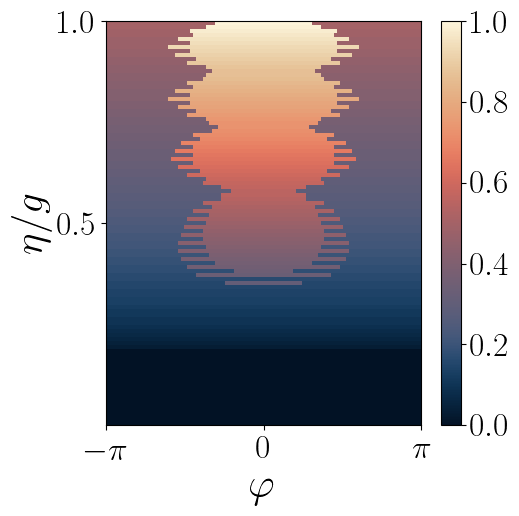

In [184]:
### Phase diagram of the cavity field (phase or amplitude variance)

x = φ_vals./π
y = η_vals./g


cmap = lipari

xtick_locs = [-1.0, 0,  1.0]  # x = φ/π
xtick_labels = [L"-\pi", L"0", L"\pi"]
ytick_locs = [0.5, 1.0]  # y = η/g
ytick_labels = [L"0.5", L"1.0"]

fig, axs = subplots(1, 1, figsize=(5.5, 5.5))


im1 = imshow(((fpeak_N2)./maximum(fpeak_N2))',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=cmap)     
axs.set_ylabel(L"\eta/g")
axs.set_xlabel(L"\varphi")

axs.set_xticks(xtick_locs)
axs.set_xticklabels(xtick_labels)
axs.set_yticks(ytick_locs)
axs.set_yticklabels(ytick_labels)


# fncx = (0.238 .* (cos.(0.83.*x.* pi)) .+0.395) # Function for the line in the phase diagram
# axs.plot(x, fncx, color="white", linewidth=2.5)

cbar = colorbar(im1, ax=axs)

#Cbar ticks
# cbar.set_ticks([0, 1.0])
# cbar.set_ticklabels([L"0", L"1"])

#Set colorbar label as the variance of N1 and N2, horizontally aligned on top of the colorbar
# cbar.ax.set_title(L"\tilde{\omega}(|\alpha|^2)", pad=13)

#Add text description to the two states inside phase diagram
# axs.text(0.0, 0.4, L"\textbf{SS}", fontsize=35, ha="center", va="center", color="white")
# axs.text(0.0, 0.8, L"\textbf{NSS}", fontsize=35, ha="center", va="center",color="black")
tight_layout()
display(fig)
#savefig("../figs/spin1/var_argcav.pdf", bbox_inches="tight", dpi=800)

In [ ]:
#writedlm("fourier_spin1.txt", fpeak_adaga)

In [ ]:
# Fixed parameters
g, κ = 0.1, 1.0
Δ1, Δ2 = 0,0#2pi*0.1*g,2pi*0.07*g 
Δ = 0
ϕ = 0
η = 0.25*g 
# Time steps
tend = 10000.0/g;
t_list = range(0.0, tend, length=10001);

# Initial conditions
u0 = zeros(10);  
for i in 1:8
    u0[i] = tr(rho0*λ_matrices[i])
end

params = (Δ1, Δ2, g, ϕ, Δ, κ, η);
prob = ODEProblem(coupled_eqs!, u0, (0.0, tend), params);
sol = solve(prob, Tsit5(), saveat=t_list, reltol=1e-6, abstol=1e-6);  # If stiff solver needed → pass "TRBDF2(autodiff=false)" to solve()

λ = sol[1:8, :]         # 8×Nt array of λ₁..λ₈
t = sol.t               # time vector
Nt = length(t)

# Compute Ni and quadratic Casimir if needed
N0 = (1/3 .- sol[3,:] .+ 1/sqrt(3).*sol[8,:])
N1 = (1/3 .+ sol[3,:] .+ 1/sqrt(3).*sol[8,:])
N2 =  (1/3 .- 2/sqrt(3).*sol[8,:]);

In [ ]:
N  = length(t_list)
steady_idx = collect(div(length(t_list), 2) : length(t_list))
Ts = 1 / (1.1 * N)
# Sample rate
fs = 1 / Ts

N0_ss    = @. 1/3 - sol[3, :] + (1/√3) * sol[8, :]
N1_ss    = @. 1/3 + sol[3, :] + (1/√3) * sol[8, :]
N2_ss    = @. 1/3 - (2/√3) * sol[8, :]
adaga_ss = @. 1/2 * (sol[9, :]^2 + im * sol[10, :]^2 - 1)


# (4) Restrict to positive half (skip DC at index 1)
Nhalf      = div(length(N0_ss), 2)
pos_range  = 1:(Nhalf)   # bins 2 through Nhalf+1

fft_N0 = fft(N0_ss .- mean(N0_ss))
fft_N1 = fft(N1_ss .- mean(N1_ss))
fft_N2 = fft(N2_ss .- mean(N2_ss))
fft_adaga = fft(adaga_ss .- mean(adaga_ss))





# fft_N0 = fftshift(fft(N0_ss))
# fft_N1 = fftshift(fft(N1_ss))
# fft_N2 = fftshift(fft(N2_ss))
# fft_adaga = fftshift(fft(adaga_ss))

# freqs =  fftshift(fftfreq(length(t_list), fs))          


fig, ax = subplots(1, 4, figsize = (12, 4))



ax[1].plot(abs.(fft_N1)[pos_range], lw = 4)
ax[1].set_xlabel(L"N_1")
ax[1].set_xlim(0,4000)
# ax[1].vlines(29.5,0,maximum( abs.(fft_N0)), lw=3, color="black")

# ax[1].set_ylim(0,0.05)

ax[2].plot(abs.(fft_N0)[pos_range], lw = 4)
ax[2].set_xlabel(L"N_0")
ax[2].set_xlim(0,4000)
# ax[2].vlines(29.5,0,maximum( abs.(fft_N0)), lw=3, color="black")
# ax[2].set_ylim(0,0.05)


ax[3].plot( abs.(fft_N2)[pos_range], lw = 4)
ax[3].set_xlabel(L"N_2")
ax[3].set_xlim(0,4000)
# ax[3].vlines(29.5,0,maximum( abs.(fft_N0)), lw=3, color="black")
# ax[3].set_ylim(0,0.05)

ax[4].plot(N0, lw = 4, label=L"N_0")
ax[4].plot(N1, lw = 4, label=L"N_1")
ax[4].plot(N2, lw = 4, label=L"N_2")
ax[4].legend(fontsize=18)
ax[4].set_xscale("log")
ax[4].set_xlabel("Time")

tight_layout()

display(fig)

In [ ]:
k_arg = argmax(abs.(fft_N0))  ≥ A_thresh ? argmax(abs.(fft_N0))  : 0


In [622]:
tend = 100000.0/g;
  t_list = range(0.0, tend, length=10001);

# Parameter setup
η_vals  = range(0.1*g, 1.0*g, length=21)
φ_vals  = range(-π, π, length=21)
N       = length(t_list)
steady_idx = collect(div(N,2):N)        # second‐half as before

# FFT bins
n_freq = div(N,2)
dt     = t_list[2] - t_list[1]
fs     = 1/dt
freqs  = fs * (1:n_freq) ./ N

# Preallocate 3D arrays
P_spec    = zeros(Float64, n_freq, length(φ_vals), length(η_vals))
phase_dom = zeros(Float64, length(φ_vals), length(η_vals))

# Main double loop
for (iφ, φ_val) in enumerate(φ_vals)
  for (iη, η_val) in enumerate(η_vals)
    # (1) Solve ODE
    params = (0.1g, 0.1g, g, φ_val, Δ, κ, η_val,0)
    prob   = ODEProblem(coupled_eqs!, u0, (0.0, tend), params)
    sol    = solve(prob, Tsit5(); saveat = t_list,
                             reltol = 1e-6, abstol = 1e-6)

    # (2) Extract steady |a|^2
    adaga_ss = sol[9, steady_idx] .+ im .* sol[10, steady_idx]

    # (3) FFT & power
    fft_vals = fft(adaga_ss)
    fft_vals = fft_vals[2:n_freq+1]         
    P1       = abs.(fft_vals) ./ N
    P_spec[:, iφ, iη] = P1                   

    # (4) record phase of the dominant line
    k_peak = argmax(P1)
    phase_dom[iφ, iη] = angle(fft_vals[k_peak])
  end
end


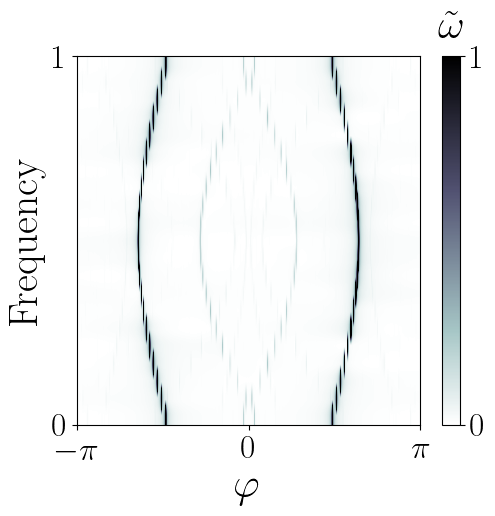

In [623]:

# — now pick one η‐slice  —
iη0 = 1*div(length(η_vals), 20)
P_slice = P_spec[:, :, iη0]   # size (n_freq × nφ)

# normalize for plotting
P_norm = P_slice ./ maximum(P_slice)

# prepare your φ and freq axes
x = collect(φ_vals)
y = freqs

# your ticks
xtick_locs   = [-π, 0, π]
xtick_labels = [L"-\pi", L"0", L"\pi"]
ytick_locs   = [y[1],  y[end]]
ytick_labels = [L"0", L"1"]

# plot the spectrogram for η = η_vals[iη0]
cmap = "bone_r"
fig, axs = subplots(1,1, figsize=(5.5,5.5))

im1 = axs.imshow(
    P_norm', 
    extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
    origin="lower",
    aspect="auto",
    cmap=cmap,
    clim=(0,0.05)
)
axs.set_xlabel(L"\varphi")
axs.set_ylabel(L"\mathrm{Frequency}")

axs.set_xticks(xtick_locs)
axs.set_xticklabels(xtick_labels)
axs.set_yticks(ytick_locs)
axs.set_yticklabels(ytick_labels)


cbar = colorbar(im1, ax=axs)
cbar.set_ticks([0,0.05])
cbar.set_ticklabels([L"0",L"1"])
cbar.ax.set_title(L"\tilde{\omega}", pad=13)


tight_layout()
display(fig)


In [ ]:
# ——— define your parameter sets —————————————————————————————————————
# here we sweep, say, three different η values as an example:
param_sets = [
    (ϕ=3pi/5, η=0.5*g),
    (ϕ=0, η=0.75*g),
    (ϕ=0, η=0.5*g),
]

# ——— run all simulations ————————————————————————————————————————
solutions = Vector{ODESolution}(undef, length(param_sets))

for (i, ps) in enumerate(param_sets)
    p = (0, 0, g, ps.ϕ, Δ, κ, ps.η)
    prob = ODEProblem(coupled_eqs!, copy(u0), (0.0, tend), p)
    solutions[i] = solve(prob, Tsit5(), saveat=t_list, reltol=1e-6, abstol=1e-6)
end

# ——— now plot λ₃–λ₈ phase portraits overlayed —————————————————————
fig, ax = subplots(figsize=(6,6))
ax.set_aspect("equal")
ax.set_xlabel(L"\lambda_3")
ax.set_ylabel(L"\lambda_8")
ax.grid(true, linestyle="--", alpha=0.3)

# choose one colormap per run
cmaps   = [get_cmap("RdBu"), get_cmap("PuBuGn"), get_cmap("RdYlBu")]
markers = ["o", "o", "o"]  # circle, cross, triangle
sizes = [15,15,15]
for (k, sol) in enumerate(solutions)
    λ    = sol[1:8, :]             # 8×Nt
    λ3, λ8 = λ[3, :], λ[8, :]
    tnorm   = (sol.t .- sol.t[1]) ./ (sol.t[end] - sol.t[1])
    cmap    = cmaps[k]
    colors  = cmap.(tnorm)
    m       = markers[k]
    szs       = sizes[k]
    sc = ax.scatter(λ3, λ8;
        c         = colors,
        s         = szs,
        alpha     = 0.8,
        marker    = m,
        edgecolors="none"
    )

    markercolors = ["navy", "forestgreen", "crimson"]
    # mark start and end
    ax.scatter(λ3[1], λ8[1], marker="*", s=180, c="white", edgecolors="black")
    ax.scatter(λ3[end], λ8[end],marker="o", s=75, c=markercolors[k], edgecolors="black")
end
display(fig)

In [ ]:

# ——— define your parameter sets —————————————————————————————————————
param_sets = [
    (ϕ = 3π/5, η = 0.5*g),
    (ϕ = 0,   η = 0.75*g),
    (ϕ = 0,   η = 0.5*g),
]

# pre‐allocate
solutions = Vector{ODESolution}(undef, length(param_sets))

for (i, ps) in enumerate(param_sets)
    p    = (0, 0, g, ps.ϕ, Δ, κ, ps.η)
    prob = ODEProblem(coupled_eqs!, copy(u0), (0.0, tend), p)
    sol  = solve(prob, Tsit5(), saveat=t_list, reltol=1e-6, abstol=1e-6)
    solutions[i] = sol

    # extract λ₃ and λ₈
    λ3 = sol[3, :]
    λ8 = sol[8, :]
    t  = sol.t

    # write a file named run_i.txt with columns t,λ3,λ8
    fname = "run_$(i).txt"
    data = hcat(t, λ3, λ8)
    writedlm(fname, data)
    println("Wrote ", fname)
end

In [108]:

φ_val = pi/2
η_val = 0.5 * g
params = (0.0, 0.0, g, φ_val, Δ, κ, η_val, γ)


tend = 200.0 / g
t_list = range(0.0, tend, length=5001)
steady_idx = div(length(t_list), 2):length(t_list)
fs = 1 / (t_list[2] - t_list[1])

# Grid for a and b
a_vals = range(-1, 1, length=201)
b_vals = range(-1, 1, length=201)
peak_amp = zeros(length(a_vals), length(b_vals))


for (i, a) in enumerate(a_vals)
    for (j, b) in enumerate(b_vals)
        if a^2 + b^2 <= 0.999
            c = sqrt(1 - a^2 - b^2)
            ψ = [a, c, b]  # ψ = a*A + c*O + b*B
            ρ0 = ψ * ψ'
            ρ0 /= tr(ρ0)
            
            u0 = zeros(10)
            for k in 1:8
                u0[k] = real(tr(ρ0 * λ_matrices[k]))
            end
            
            prob = ODEProblem(coupled_eqs!, u0, (0.0, tend), params)
            sol = solve(prob, Tsit5(); saveat=t_list, reltol=1e-6, abstol=1e-6)
            
            N2_ss = @. 1/3 - (2/√3) * sol[8, steady_idx]
            N2_ss .-= mean(N2_ss)
            fft_N2 = fft(N2_ss)
            amp = maximum(abs.(fft_N2[2:end]))  # Skip DC component
            peak_amp[i, j] = amp
        else
            peak_amp[i, j] = 0
        end
    end
end
normalized_amp = peak_amp ./ maximum(peak_amp);

In [109]:
### Save data
η_g= η_val/g

filename = "a_vs_b_eta=$(η_g)_ϕ=$(φ_val).txt"
open(filename, "w") do file

    write(file, "# Parameters: φ=$φ_val, η=$η_val, g=$g, Δ=$Δ, κ=$κ, γ=$γ\n")
    write(file, "# a_values: $(collect(a_vals))\n")
    write(file, "# b_values: $(collect(b_vals))\n")
    write(file, "# Data format: a, b, normalized_amplitude\n")
    

    for i in 1:length(a_vals)
        for j in 1:length(b_vals)
            a = a_vals[i]
            b = b_vals[j]
            amp = normalized_amp[i, j]
            write(file, "$a\t$b\t$amp\n")
        end
    end
end

println("Data saved to $filename")

Data saved to a_vs_b_eta=0.5_ϕ=1.5707963267948966.txt


$\eta$ slice parameter space

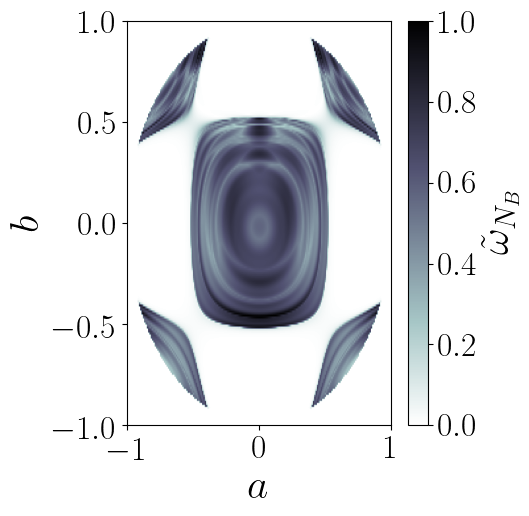

In [110]:
# Create the plot
fig, ax = subplots(1, 1, figsize=(5.5, 5.5))

# Create heatmap
im1 = ax.imshow(normalized_amp', 
               extent=(minimum(a_vals), maximum(a_vals), minimum(b_vals), maximum(b_vals)),
               origin="lower",
               aspect="auto", 
               cmap="bone_r")  


ax.set_xlabel(L"a")
ax.set_ylabel(L"b")


cbar = colorbar(im1, ax=ax)
cbar.set_label(L"$\tilde{\omega}_{N_{B}}$")


tight_layout()


display(fig)

In [54]:
φ = 0
eta_ratios = 0.8:-0.01:0.01
threshold = 0.01

# Time parameters
tend = 100.0 / g
t_list = range(0.0, tend, length=1001)
steady_idx = div(length(t_list), 2):length(t_list)
fs = 1 / (t_list[2] - t_list[1])

a_vals = range(-1, 1, length=151)
b_vals = range(-1, 1, length=151)

# Precompute data for each η/g
data_slices = Dict()

# Progress tracking
println("Starting computation for $(length(eta_ratios)) η/g values")
progress = 0

for η_ratio in eta_ratios
    η_val = η_ratio * g
    params = (0.0, 0.0, g, φ, Δ, κ, η_val, γ)
    peak_amp = zeros(length(a_vals), length(b_vals))
    
    for (i, a) in enumerate(a_vals)
        for (j, b) in enumerate(b_vals)
            if a^2 + b^2 ≤ 0.995
                c = sqrt(1 - a^2 - b^2)
                ψ = [a, c, b]
                ρ0 = ψ * ψ'
                ρ0 /= tr(ρ0)
                
                u0 = zeros(10)
                for k in 1:8
                    u0[k] = real(tr(ρ0 * λ_matrices[k]))
                end
                
                prob = ODEProblem(coupled_eqs!, u0, (0.0, tend), params)
                sol = solve(prob, Tsit5(); saveat=t_list, reltol=1e-6, abstol=1e-6)
                
                N2_ss = @. 1/3 - (2/√3) * sol[8, steady_idx]
                N2_ss .-= mean(N2_ss)
                fft_N2 = fft(N2_ss)
                amp = maximum(abs.(fft_N2[2:end]))
                peak_amp[i, j] = amp
            else
                peak_amp[i, j] = 0.0
            end
        end
    end
    normalized_amp = peak_amp ./ maximum(peak_amp)
    data_slices[η_ratio] = normalized_amp
    
    # Update progress
    progress += 1
    println("Completed $progress/$(length(eta_ratios)) (η/g = $η_ratio)")
end

Starting computation for 80 η/g values
Completed 1/80 (η/g = 0.8)
Completed 2/80 (η/g = 0.79)
Completed 3/80 (η/g = 0.78)
Completed 4/80 (η/g = 0.77)
Completed 5/80 (η/g = 0.76)
Completed 6/80 (η/g = 0.75)
Completed 7/80 (η/g = 0.74)
Completed 8/80 (η/g = 0.73)
Completed 9/80 (η/g = 0.72)
Completed 10/80 (η/g = 0.71)
Completed 11/80 (η/g = 0.7)
Completed 12/80 (η/g = 0.69)
Completed 13/80 (η/g = 0.68)
Completed 14/80 (η/g = 0.67)
Completed 15/80 (η/g = 0.66)
Completed 16/80 (η/g = 0.65)
Completed 17/80 (η/g = 0.64)
Completed 18/80 (η/g = 0.63)
Completed 19/80 (η/g = 0.62)
Completed 20/80 (η/g = 0.61)
Completed 21/80 (η/g = 0.6)
Completed 22/80 (η/g = 0.59)
Completed 23/80 (η/g = 0.58)
Completed 24/80 (η/g = 0.57)
Completed 25/80 (η/g = 0.56)
Completed 26/80 (η/g = 0.55)
Completed 27/80 (η/g = 0.54)
Completed 28/80 (η/g = 0.53)
Completed 29/80 (η/g = 0.52)
Completed 30/80 (η/g = 0.51)
Completed 31/80 (η/g = 0.5)
Completed 32/80 (η/g = 0.49)
Completed 33/80 (η/g = 0.48)
Completed 34/80 (

In [55]:
# Save data as a dictionary for conciseness
using NPZ

# Create a new dictionary with arrays only (no nested dictionaries)
save_dict = Dict{String, Any}()

# Save basic arrays
save_dict["a_vals"] = a_vals
save_dict["b_vals"] = b_vals
save_dict["eta_ratios"] = eta_ratios

# Save each data slice as a separate array
for (i, η_ratio) in enumerate(eta_ratios)
    key_name = "data_slice_$(η_ratio)"
    save_dict[key_name] = data_slices[η_ratio]
end

# Now save the dictionary
npzwrite("ab_eta_slices.npz", save_dict)

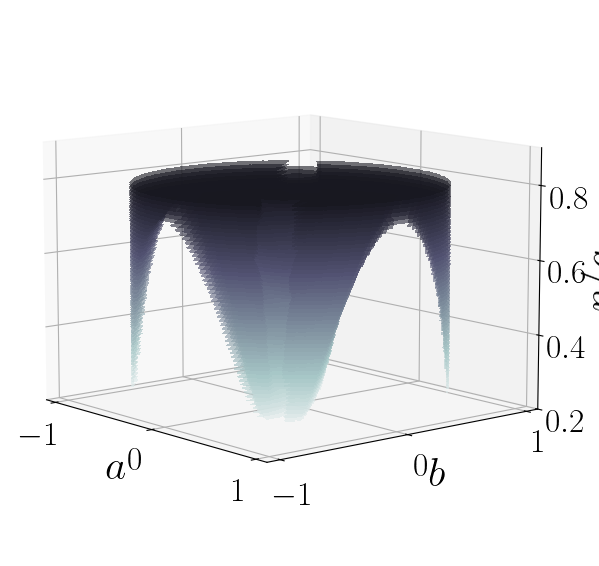

In [50]:
using PyPlot


threshold = 0.2

bone_cmap = plt.get_cmap("bone_r")
colormap_positions = 0.1 .+ 0.8 .* (eta_ratios .- 0.25) ./ (0.8 - 0.25)
clist = [bone_cmap(pos) for pos in colormap_positions]

highlight_points = [(0, 0), (1, 1), (-1, -1), (1, -1), (-1, 1)]

# Create 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Generate grid for a and b values
A = repeat(a_vals', length(b_vals), 1)
B = repeat(b_vals, 1, length(a_vals))

for (i,η_ratio) in enumerate(eta_ratios)
    normalized_amp = data_slices[η_ratio]
    
    # Create mask for values above threshold
    mask = normalized_amp .>= threshold

    contour_color = clist[i]

    cs = ax.contourf(
        A, B, mask,
        levels=[0.5, 1.5],  # Binary levels
        colors=[contour_color],
        alpha=0.6,
        zdir="z",
        offset=η_ratio
    )
    # Draw the circle a² + b² = 1 at this z-level
    theta = range(0, 2π, length=100)
    a_circle = 0.995*cos.(theta)
    b_circle = 0.995*sin.(theta)
    z_circle = fill(η_ratio, length(theta))
    
    # ax.plot(a_circle, b_circle, z_circle, color="grey", linestyle="-", linewidth=3)

    # # Add scatter for the last η
    # if η_ratio == η_ratio[end]
    #     points = [
    #         (1/√2, 1/√2, "darkorange"),
    #         (-1/√2, -1/√2, "darkorange"),
    #         (1/√2, -1/√2, "grey"),
    #         (-1/√2, 1/√2, "grey"),
    #         (0, 0, "darkorange")
    #     ]
        
    #     for point in points
    #         a, b, color = point
    #         ax.scatter(a, b, η_ratio, color=color, s=50, alpha=0.75)
    #     end
    # end

end

ax.set_xlabel(L"a")
ax.set_ylabel(L"b") 
ax.set_zlabel(L"\eta/g")
ax.set_xticks([-1,0,1])
ax.set_yticks([-1,0,1])
# ax.set_zticks([0.45,0.85])

ax.view_init(elev=10, azim=-40)

# Set limits to match your data range
ax.set_xlim(minimum(a_vals)-0.1, maximum(a_vals) + 0.1)
ax.set_ylim(minimum(b_vals)-0.1, maximum(b_vals) + 0.1)
ax.set_zlim(0.20, 0.9)

plt.tight_layout()
display(fig)

In [18]:
# System parameters
g = 0.1
κ = 1.0
η = 0.7 * g
ϕ = 2*pi/3

# Time parameters
tend = 2000 / g
t_list = range(0.0, tend, length=500)
t_array = collect(t_list)
dt = t_array[2] - t_array[1]

# steady window indices (second half)
steady_idx = collect(div(length(t_array), 2) : length(t_array))

# helper that runs one simulation for a given Δ and returns computed arrays
function run_sim_threelevel(Δ)
    params = (0.0, 0.0, g, ϕ, Δ, κ, η, 0)
    
    # Choose a representative initial state (e.g., mostly in state A)
    a, b = 0.8, 0.1  # representative values
    c = sqrt(1 - a^2 - b^2)
    ψ = [a, c, b]
    ρ0 = ψ * ψ'
    ρ0 /= tr(ρ0)
    
    u0 = zeros(10)
    for k in 1:8
        u0[k] = real(tr(ρ0 * λ_matrices[k]))
    end
    
    prob = ODEProblem(coupled_eqs!, u0, (0.0, tend), params)
    sol = solve(prob, Tsit5(); saveat=t_array, reltol=1e-6, abstol=1e-9)

    # Extract population time series
    N0_t = @. 1/3 - sol[3, :] + (1/√3) * sol[8, :]
    N1_t = @. 1/3 + sol[3, :] + (1/√3) * sol[8, :]
    N2_t = @. 1/3 - (2/√3) * sol[8, :]      
    # Steady state window
    N0_steady = N0_t[steady_idx]
    N1_steady = N1_t[steady_idx]
    N2_steady = N2_t[steady_idx]
    
    fft_N0 = fft(N0_steady)
    fft_N1 = fft(N1_steady)
    fft_N2 = fft(N2_steady)
    
    N = length(N2_steady)
    df = 1.0 / (N * dt)
    freq = df .* (0:(N-1))
    Nhalf = div(N, 2)
    
    # Amplitude spectrum
    amp_N0 = abs.(fft_N0)
    amp_N1 = abs.(fft_N1)
    amp_N2 = abs.(fft_N2)

    
    return Dict(
        :N0_steady => N0_steady,
        :N1_steady => N1_steady,
        :N2_steady => N2_steady,
        :amp_N0 => amp_N0,
        :amp_N1 => amp_N1,
        :amp_N2 => amp_N2,
        :freq => freq,
        :Nhalf => Nhalf
    )
end

# Detuning values to compare
delta_vals = [0.0, 0.15 * g]

# run simulations
results_3level = Dict{Float64,Any}()
for Δ in delta_vals
    results_3level[Δ] = run_sim_threelevel(Δ)
end

# Create figure with similar layout to spin case
fig, axes = subplots(1, 2, figsize=(6, 4),
                     gridspec_kw=Dict("width_ratios" => [5, 1.5], "wspace" => 0.050))
ax1, ax2 = axes[1], axes[2]

# Colors and styles
cs = ["dodgerblue", "crimson"]  # for potential multiple observables
t_steady = t_array[steady_idx]

# Plot time dynamics on left subplot (ax1)
for (i, Δ) in enumerate(delta_vals)
    res = results_3level[Δ]
    
    if Δ == delta_vals[2]
        lsi = "--"
        ai = 0.6
        label_N0 = ""
        label_N1 = ""
        label_N2 = ""
    else
        lsi = "-"
        ai = 1.0
        label_N0 = L"N_0"
        label_N1 = L"N_1"
        label_N2 = L"N_2"
    end
    

    # ax1.plot(t_steady[1:100], res[:N0_steady][1:100], 
    #         lw=4, c="olive", ls=lsi, alpha=ai, label=label_N0)
    ax1.plot(t_steady[1:100], res[:N1_steady][1:100], 
            lw=4, c="teal", ls=lsi, alpha=ai, label=label_N1
           )
    ax1.plot(t_steady[1:100], res[:N2_steady][1:100], 
            lw=4, c="coral", ls=lsi, alpha=ai, label=label_N2)
end

# Set left subplot properties
ax1.set_ylim(0, 1)  # Population between 0 and 1
ax1.set_yticks([0, 0.5, 1])
ax1.set_yticklabels([L"0", L"0.5", L"1"])
ax1.set_xlabel(L"Time $(1/g)\times10^5$")
ax1.set_xticks([10000, 12000,14000], [L"1", L"1.2", L"1.4"])
ax1.set_ylabel("Relative pop.", labelpad=-5)
ax1.legend(loc="upper center")

# Plot frequency spectrum on right subplot (ax2)
for (i, Δ) in enumerate(delta_vals)
    res = results_3level[Δ]
    freq = res[:freq]
    Nhalf = res[:Nhalf]
    pos_range = 2:Nhalf  # skip DC component

    # Get positive frequency data
    freq_pos = freq[pos_range]/g
    amp_N0_pos = res[:amp_N0][pos_range]
    amp_N1_pos = res[:amp_N1][pos_range]
    amp_N2_pos = res[:amp_N2][pos_range]
    
    # Create symmetric data
    freq_sym = [-reverse(freq_pos); freq_pos]
    amp_N0_sym = [reverse(amp_N0_pos); amp_N0_pos]
    amp_N1_sym = [reverse(amp_N1_pos); amp_N1_pos]
    amp_N2_sym = [reverse(amp_N2_pos); amp_N2_pos]
    
    if Δ == delta_vals[2]
        lsi = "--"
        ai = 0.6
    else
        lsi = "-"
        ai = 0.75
    end
    
    # ax2.plot(amp_N0_sym, freq_sym, lw=3, ls=lsi, c="olive", alpha=ai)
    ax2.plot(amp_N1_sym, freq_sym, lw=3, ls=lsi, c="teal", alpha=ai)
    ax2.plot(amp_N2_sym, freq_sym, lw=3, ls=lsi, c="coral", alpha=ai)
end


ax2.set_xscale("log")
ax2.set_ylabel(L"$\omega/g$", labelpad=-35)
ax2.set_yticks([-0.1, 0.1])
ax2.set_xlabel(L"$\mathcal{F}(\omega)$")
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()

ax1.tick_params(direction="in", which="both")
ax2.tick_params(direction="in", which="both", right=true)

#display(fig)
savefig("../supmat/supmat_Delta_c_spin1.pdf", bbox_inches="tight", pad_inches=0.01)